<a href="https://colab.research.google.com/github/YokoyamaLab/PythonBasics/blob/2025/25_day07kk_ImageRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [Day07 講義内課題] 画像認識

In [ ]:
# @title 提出者情報
学籍番号 = "" # @param {"type":"string"}
名前 = "" # @param {"type":"string"}

## 解説

この講義内課題では数値が描かれた画像を読み込みそれが何の数字であるかを予測する方法を機械学習とディープラーニングを使って実装します。まず以下のコードボックスを実行して必要なライブラリを読み込んでください。

In [21]:
!pip install tensorflow

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from google.colab import files
from PIL import Image, ImageOps, ImageFilter
import cv2

数字の描かれた画像はscikit-learnに内包されていますのでそれを使います。次のボックスを実行してください。

データの形状: (1797, 8, 8)
ターゲットの形状: (1797,)


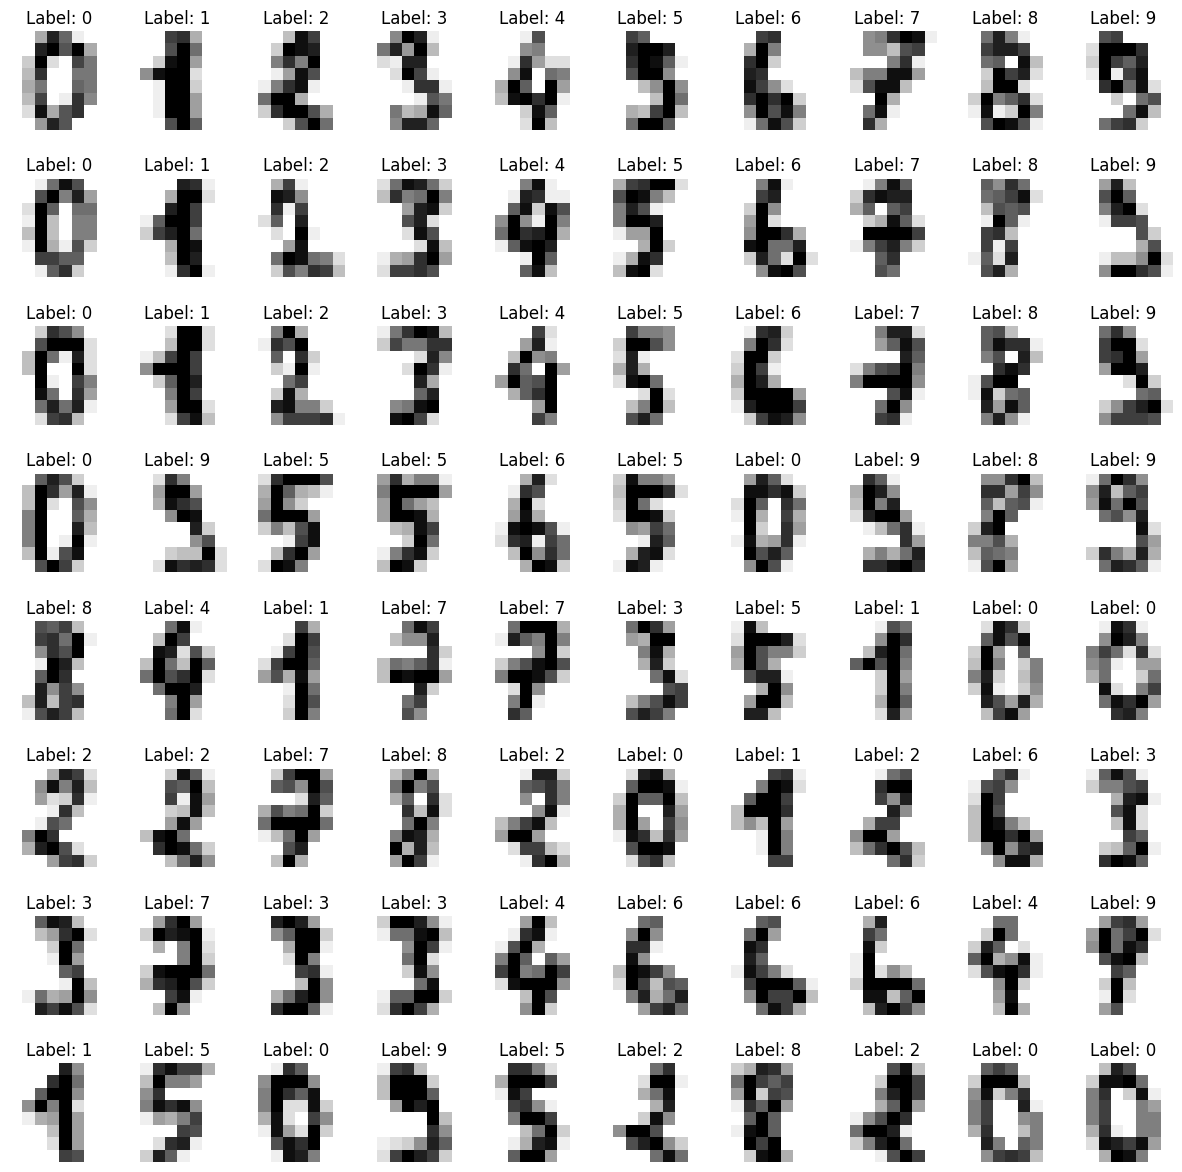

In [6]:
# データセットのロード
digits = load_digits()

# データの確認
print(f'データの形状: {digits.images.shape}')
print(f'ターゲットの形状: {digits.target.shape}')

# 最初のいくつかの画像を表示
fig, axes = plt.subplots(nrows=8, ncols=10, figsize=(15, 15))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary')
    ax.set_title(f'Label: {digits.target[i]}')
    ax.set_axis_off()
plt.show()

8ピクセル×8ピクセルの非常に荒い画像ですが、見れば何の数字がかいてあるかが分かると思います。またそれぞれの数字には正解のラベルがついています。この画像とラベルを機械学習を使って学習させます。

## ロジスティック回帰

まずは宿題でも出したロジスティック回帰で判別させてみましょう。

In [7]:
# データの整形 (画像を1次元ベクトルに変換)
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))

# 訓練データとテストデータに分割(8割で学習し、残りの2割で精度をみます)
X_train, X_test, y_train, y_test = train_test_split(data, digits.target, test_size=0.2, random_state=42)

# ロジスティック回帰モデルの作成と学習
model = LogisticRegression(max_iter=10000) # max_iterを増やして収束させる
model.fit(X_train, y_train)  # 訓練データを使って学習

# テストデータでの予測
y_pred = model.predict(X_test)

# 評価
accuracy = accuracy_score(y_test, y_pred)
print(f'テスト精度: {accuracy:.4f}')


テスト精度: 0.9750


テスト制度が1に近い値が出てきました。これは、1が全部正解を意味しますので、相当高い精度で画像に書かれた数字が識別できた事を示しています。

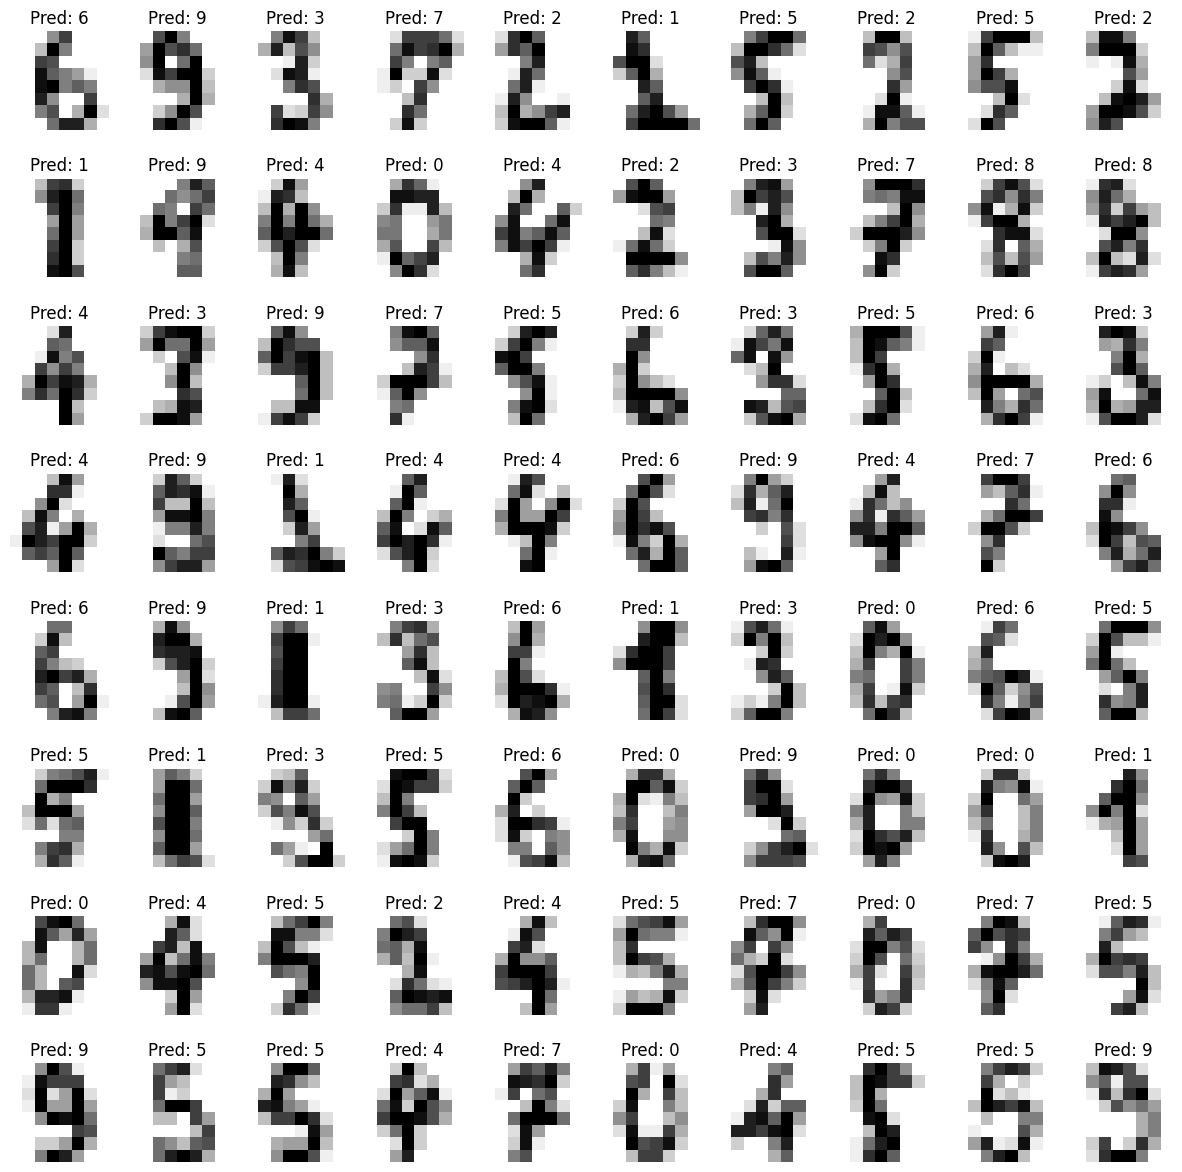

In [14]:
# 予測結果の確認 (最初のいくつかのテストデータ)
fig, axes = plt.subplots(nrows=8, ncols=10, figsize=(15, 15))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(8, 8), cmap='binary')
    ax.set_title(f'Pred: {y_pred[i]}')
    ax.set_axis_off()
plt.show()

各画像の上に書かれている数字と見比べよう、ほとんどあっているはずです。確認してみましょう。

なお上記の例はロジスティック回帰を使いました。ではこれをkeras(Googleが開発した深層学習ライブラリ)で実行してみましょう。

### 深層学習(Google Keras)

Kerasは深層学習の難しいチューニングとかをなるべく簡単な形で隠蔽した高次APIで、基本的には機械学習と同じようなfitしてpredictするという手順で使えます。

In [19]:
# ラベルデータをone-hotエンコーディングに変換
y_train_onehot = to_categorical(y_train)
y_test_onehot = to_categorical(y_test)

# ニューラルネットワークモデルの構築
model_nn = Sequential([
    # 8x8の画像をフラット化
    Flatten(input_shape=(64,)), # ロジスティック回帰でFlatten済みなので、ここは入力層
    # 隠れ層 (例として128個のニューロンを持つ層)
    Dense(256, activation='relu'),
    # 出力層 (10個のニューロン、活性化関数はsoftmaxで各数字の確率を出力)
    Dense(10, activation='softmax')
])

# モデルのコンパイル
model_nn.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# モデルの学習
history = model_nn.fit(X_train, y_train_onehot,
                       epochs=10, # エポック数を調整可能
                       batch_size=32, # バッチサイズを調整可能
                       validation_split=0.2) # 訓練データの一部を検証に使用

# テストデータでの評価
loss, accuracy_nn = model_nn.evaluate(X_test, y_test_onehot, verbose=0)
print(f'テスト精度 (ニューラルネットワーク): {accuracy_nn:.4f}')

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3328 - loss: 3.6242 - val_accuracy: 0.8611 - val_loss: 0.3938
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9045 - loss: 0.3184 - val_accuracy: 0.9236 - val_loss: 0.2420
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9583 - loss: 0.1500 - val_accuracy: 0.9271 - val_loss: 0.2084
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9703 - loss: 0.1133 - val_accuracy: 0.9236 - val_loss: 0.1853
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9884 - loss: 0.0711 - val_accuracy: 0.9479 - val_loss: 0.1464
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9918 - loss: 0.0454 - val_accuracy: 0.9375 - val_loss: 0.1448
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9861 - loss: 0.0620 - val_accuracy: 0.9618 - val_loss: 0.1322
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9953 - loss: 0.0373 - val_accuracy: 0.9549 - val_loss

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  


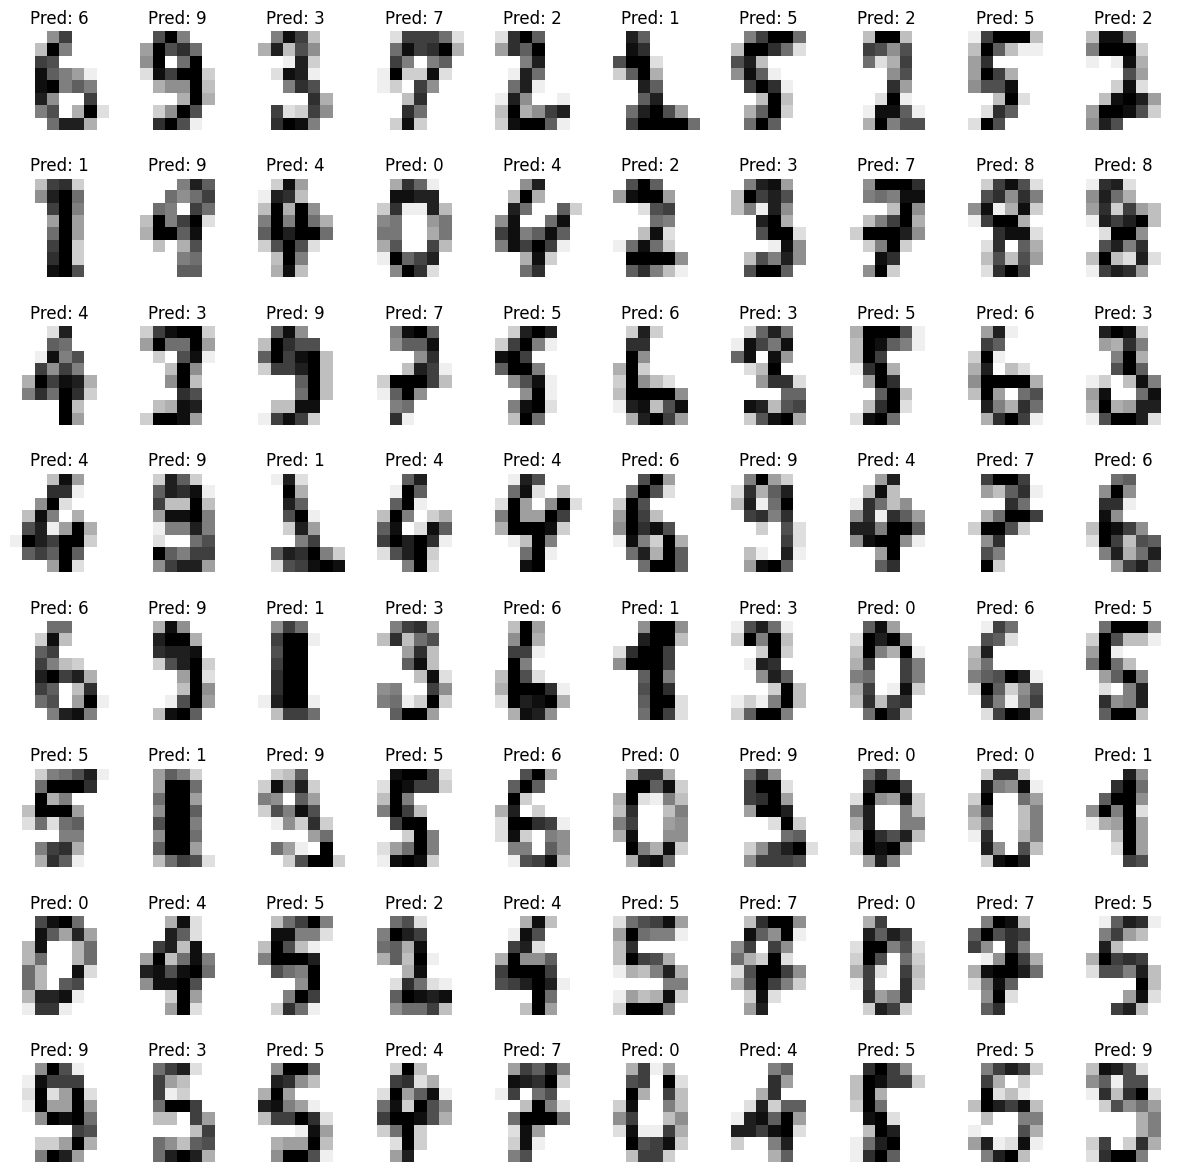

In [18]:
# 予測結果の確認 (最初のいくつかのテストデータ)
y_pred_nn_probs = model_nn.predict(X_test)
y_pred_nn = np.argmax(y_pred_nn_probs, axis=1) # 確率が最も高い数字を選択

fig, axes = plt.subplots(nrows=8, ncols=10, figsize=(15, 15))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(8, 8), cmap='binary')
    ax.set_title(f'Pred: {y_pred_nn[i]}')
    ax.set_axis_off()
plt.show()

深層学習のアルゴリズムには詳しくは立ち入りませんが、学習を繰り返していく過程で精度が上がっていく所が以下の図に表れています。(縦軸が精度)

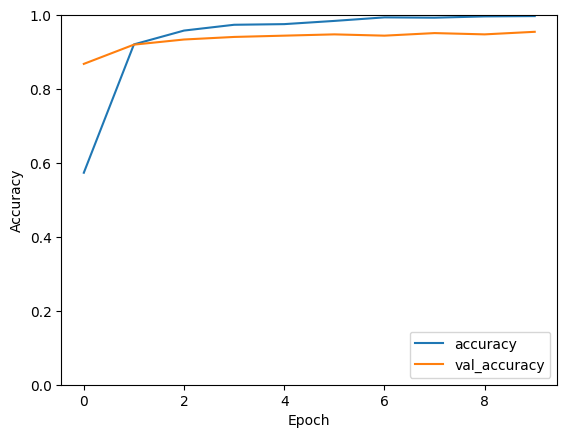

In [16]:
# 学習過程の確認 (任意)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()


## 自分の描いた画像を使う

以下のコードを実行するとファイルをアップロードするボタンが表示されます。そこに数字の描かれた画像を入れれば判定してくれるはずです。ではやってみましょう。

画像は次のツールを使うのが便利です。

https://kleki.com/?lang=ja

まず右上の新規ボタンをクリックして、正方形の画像を作ってください。10ピクセル×20ピクセル程度で良いです。そしたらブラシを極太(80～100ピクセル)変えて、数字を書いてください。最終的には8ピクセル×8ピクセルになりますので、かなり太くないと学習した絵と同じになりません。(実はこれ精度があまりよくありません、学習データとトレーニングデータは共に外国人が書いた数字で、特に7と1は日本人が書く文字と大幅に異なっています。なのでめげずに試してください。)

Saving 2025_05_28_0nb_Kleki.png to 2025_05_28_0nb_Kleki.png
Uploaded file: 2025_05_28_0nb_Kleki.png


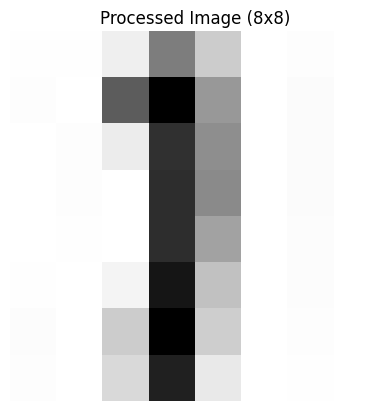

ロジスティック回帰による予測: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
ニューラルネットワークによる予測: 1


In [23]:
# ファイルアップロードダイアログを開く
uploaded = files.upload()

# アップロードされたファイルの処理
for filename in uploaded.keys():
    print(f'Uploaded file: {filename}')

    # 画像の読み込み
    img = Image.open(filename).convert('L') # グレースケールに変換

    # 画像を正方形にトリミング
    width, height = img.size
    new_dim = min(width, height)
    left = (width - new_dim) / 2
    top = (height - new_dim) / 2
    right = (width + new_dim) / 2
    bottom = (height + new_dim) / 2
    img_cropped = img.crop((left, top, right, bottom))

    # 8x8にリサイズ
    img_resized = img_cropped.resize((8, 8), Image.Resampling.LANCZOS)

    # 白黒反転 (Digitsデータセットは数字が白、背景が黒なので反転)
    img_inverted = ImageOps.invert(img_resized)

    # NumPy配列に変換し、0-16のスケールに変換 (Digitsデータセットに合わせる)
    img_array = np.array(img_inverted)
    # 最大値で正規化し、16をかけることでDigitsデータセットのスケールに近づける
    img_array = (img_array / 255.0) * 16.0

    # 8x8の一次元ベクトルに変換 (モデルの入力形式に合わせる)
    img_flattened = img_array.reshape(1, -1)

    # 処理した画像を表示 (確認用)
    plt.imshow(img_array, cmap='binary')
    plt.title('Processed Image (8x8)')
    plt.axis('off')
    plt.show()

    # ロジスティック回帰モデルで予測
    if 'model' in globals() and model is not None:
        prediction_lr = model.predict(img_flattened)
        print(f'ロジスティック回帰による予測: {prediction_lr[0]}')
    else:
        print("ロジスティック回帰モデルが学習されていません。")

    # ニューラルネットワークモデルで予測
    if 'model_nn' in globals() and model_nn is not None:
        prediction_nn_probs = model_nn.predict(img_flattened)
        prediction_nn = np.argmax(prediction_nn_probs, axis=1)
        print(f'ニューラルネットワークによる予測: {prediction_nn[0]}')
    else:
        print("ニューラルネットワークモデルが学習されていません。")


どうでしたか？

今日はこのコードになにかコードを足してすこし機能アップさせてください。